Name : Hoziyana Rachel
ID Number : 670448
Instructor : Prof Alex Mwaniki
Date : 11th / 04/ 2026
Project Presentation

 Title:Predict which borrowers are likely to default on loans.

*Objectives:
- Build a Random Forest classification model to analyze 20 financial and personal attributes (e.g., checking account status, credit history, employment duration).
- Categorize applicants into two classes: Low-risk (Approved) or High-risk (Rejected).
- Create an automated decision-engine for FinTech lending that handles complex, non-linear risk patterns better than simple models.

Success Criteria:
- Minimize false positives (approving bad borrowers), as this is the most costly error.
- Achieve high recall for high-risk borrowers to catch potential defaulters.
- Maintain overall model accuracy while prioritizing risk detection over approval rates.
- Use metrics like F1-score for risky borrowers and ROC AUC to evaluate ranking effectiveness.

Stage 2: Data Acquisition & Understanding (EDA)

The dataset was obtained from the UCI Machine Learning Repository (German Credit Dataset) and loaded into Python using the Pandas read_csv() function.


i used Germany credit dataset from UCI Machine Learning Repository 

In [110]:
import pandas as pd

# This URL contains the German Credit data WITH the target 'Risk' column
url = "https://raw.githubusercontent.com/denis-bz/pydata-2016-sk-learn/master/data/german.csv"

# The original UCI data uses numbers for columns, so we label them
# Or we can use a version that already has headers:
df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data", 
                 sep=' ', header=None)

# Adding the column names (the 21st column is the 'Risk' target)
df.columns = [
    'CheckAccount', 'Duration', 'CreditHistory', 'Purpose', 'CreditAmount', 
    'Savings', 'Employment', 'InstallmentRate', 'PersonalStatus', 'OtherDebtors', 
    'Residence', 'Property', 'Age', 'OtherInstallment', 'Housing', 
    'ExistingCredits', 'Job', 'NumLiable', 'Telephone', 'ForeignWorker', 'Risk'
]

# In this version, Risk 1 = Good, Risk 2 = Bad. 
# Let's map it to 0 and 1 for the model:
df['Risk'] = df['Risk'].map({1: 0, 2: 1}) # 0 for Good, 1 for Bad (Default)

print(df.head())
print("\nTarget Distribution:")
print(df['Risk'].value_counts())

  CheckAccount  Duration CreditHistory Purpose  CreditAmount Savings  \
0          A11         6           A34     A43          1169     A65   
1          A12        48           A32     A43          5951     A61   
2          A14        12           A34     A46          2096     A61   
3          A11        42           A32     A42          7882     A61   
4          A11        24           A33     A40          4870     A61   

  Employment  InstallmentRate PersonalStatus OtherDebtors  ...  Property Age  \
0        A75                4            A93         A101  ...      A121  67   
1        A73                2            A92         A101  ...      A121  22   
2        A74                2            A93         A101  ...      A121  49   
3        A74                2            A93         A103  ...      A122  45   
4        A73                3            A93         A101  ...      A124  53   

   OtherInstallment Housing ExistingCredits   Job NumLiable  Telephone  \
0           

| Column        | Meaning                    |
| ------------- | -------------------------- |
| CheckAccount  | Status of checking account |
| Duration      | Loan duration (months)     |
| CreditHistory | Past credit history        |
| Purpose       | Why the loan was taken     |
| CreditAmount  | Amount of credit           |
| Savings       | Savings account status     |
| Employment    | Employment duration        |
| Column         | Meaning                 |
| -------------- | ----------------------- |
| PersonalStatus | Gender + marital status |
| Age            | Age of customer         |
| Housing        | Housing situation       |
| Job            | Job type                |
| Column         | Meaning                 |
| -------------- | ----------------------- |
| PersonalStatus | Gender + marital status |
| Age            | Age of customer         |
| Housing        | Housing situation       |
| Job            | Job type                |
| Column           | Meaning                           |
| ---------------- | --------------------------------- |
| OtherDebtors     | Other people responsible for loan |
| Residence        | Years living at current residence |
| Property         | Property owned                    |
| OtherInstallment | Other installment plans           |
| Telephone        | Whether customer has phone        |
| ForeignWorker    | Foreign worker status             |


In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is your loaded dataframe containing the 'Risk' column
# If you are using the UCI version, ensure columns are named correctly.

# 1. Dataset Shape, Info, and Summary Statistics
print("--- 1. Dataset Overview ---")
print(f"Dataset Shape: {df.shape}")
print("\n--- Data Info ---")
print(df.info())
print("\n--- Summary Statistics (Numerical) ---")
print(df.describe())

--- 1. Dataset Overview ---
Dataset Shape: (1000, 21)

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CheckAccount      1000 non-null   object
 1   Duration          1000 non-null   int64 
 2   CreditHistory     1000 non-null   object
 3   Purpose           1000 non-null   object
 4   CreditAmount      1000 non-null   int64 
 5   Savings           1000 non-null   object
 6   Employment        1000 non-null   object
 7   InstallmentRate   1000 non-null   int64 
 8   PersonalStatus    1000 non-null   object
 9   OtherDebtors      1000 non-null   object
 10  Residence         1000 non-null   int64 
 11  Property          1000 non-null   object
 12  Age               1000 non-null   int64 
 13  OtherInstallment  1000 non-null   object
 14  Housing           1000 non-null   object
 15  ExistingCredits   1000 non-null   

Data Cleaning & Preprocessing

CONVERTING THE CATEGORICAL FEATURES INTO ONE HOT ENCODING    because the model might treat them as having an order or value (e.g., A11 < A12 < A14), which is wrong.

One-hot encoding converts each category into a separate binary column (0 or 1):

In [112]:
import pandas as pd

# Load dataset
df = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data",
    sep=' ',
    header=None
)

# Add column names
df.columns = [
    'CheckAccount', 'Duration', 'CreditHistory', 'Purpose', 'CreditAmount', 
    'Savings', 'Employment', 'InstallmentRate', 'PersonalStatus', 'OtherDebtors', 
    'Residence', 'Property', 'Age', 'OtherInstallment', 'Housing', 
    'ExistingCredits', 'Job', 'NumLiable', 'Telephone', 'ForeignWorker', 'Risk'
]

# Convert target
df['Risk'] = df['Risk'].map({1: 0, 2: 1})

# One-hot encoding
df_encoded = pd.get_dummies(df, drop_first=True)

print(df_encoded.head())

   Duration  CreditAmount  InstallmentRate  Residence  Age  ExistingCredits  \
0         6          1169                4          4   67                2   
1        48          5951                2          2   22                1   
2        12          2096                2          3   49                1   
3        42          7882                2          4   45                1   
4        24          4870                3          4   53                2   

   NumLiable  Risk  CheckAccount_A12  CheckAccount_A13  ...  Property_A124  \
0          1     0             False             False  ...          False   
1          1     1              True             False  ...          False   
2          2     0             False             False  ...          False   
3          2     0             False             False  ...          False   
4          2     1             False             False  ...           True   

   OtherInstallment_A142  OtherInstallment_A143  Housing

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is your loaded dataframe containing the 'Risk' column
# If you are using the UCI version, ensure columns are named correctly.

# 1. Dataset Shape, Info, and Summary Statistics
print("--- 1. Dataset Overview ---")
print(f"Dataset Shape: {df_encoded.shape}")
print("\n--- Data Info ---")
print(df_encoded.info())
print("\n--- Summary Statistics (Numerical) ---")
print(df_encoded.describe())

--- 1. Dataset Overview ---
Dataset Shape: (1000, 49)

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 49 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Duration               1000 non-null   int64
 1   CreditAmount           1000 non-null   int64
 2   InstallmentRate        1000 non-null   int64
 3   Residence              1000 non-null   int64
 4   Age                    1000 non-null   int64
 5   ExistingCredits        1000 non-null   int64
 6   NumLiable              1000 non-null   int64
 7   Risk                   1000 non-null   int64
 8   CheckAccount_A12       1000 non-null   bool 
 9   CheckAccount_A13       1000 non-null   bool 
 10  CheckAccount_A14       1000 non-null   bool 
 11  CreditHistory_A31      1000 non-null   bool 
 12  CreditHistory_A32      1000 non-null   bool 
 13  CreditHistory_A33      1000 non-null   bool 
 14  CreditHistory_A3

In [130]:
# 3. Missing or Duplicate Data
print("\n--- 3. Data Quality Check ---")
print("Missing Values:\n", df_encoded.isnull().sum())
print("\nDuplicate Rows:", df_encoded.duplicated().sum())


--- 3. Data Quality Check ---
Missing Values:
 Duration                 0
CreditAmount             0
InstallmentRate          0
Residence                0
Age                      0
ExistingCredits          0
NumLiable                0
Risk                     0
CheckAccount_A12         0
CheckAccount_A13         0
CheckAccount_A14         0
CreditHistory_A31        0
CreditHistory_A32        0
CreditHistory_A33        0
CreditHistory_A34        0
Purpose_A41              0
Purpose_A410             0
Purpose_A42              0
Purpose_A43              0
Purpose_A44              0
Purpose_A45              0
Purpose_A46              0
Purpose_A48              0
Purpose_A49              0
Savings_A62              0
Savings_A63              0
Savings_A64              0
Savings_A65              0
Employment_A72           0
Employment_A73           0
Employment_A74           0
Employment_A75           0
PersonalStatus_A92       0
PersonalStatus_A93       0
PersonalStatus_A94       0
OtherDe

Exploratory Data Analysis (EDA)

=== Descriptive Statistics ===
          Duration  CreditAmount  InstallmentRate    Residence          Age  \
count  1000.000000   1000.000000      1000.000000  1000.000000  1000.000000   
mean     20.903000   3271.258000         2.973000     2.845000    35.546000   
std      12.058814   2822.736876         1.118715     1.103718    11.375469   
min       4.000000    250.000000         1.000000     1.000000    19.000000   
25%      12.000000   1365.500000         2.000000     2.000000    27.000000   
50%      18.000000   2319.500000         3.000000     3.000000    33.000000   
75%      24.000000   3972.250000         4.000000     4.000000    42.000000   
max      72.000000  18424.000000         4.000000     4.000000    75.000000   

       ExistingCredits    NumLiable         Risk  
count      1000.000000  1000.000000  1000.000000  
mean          1.407000     1.155000     0.300000  
std           0.577654     0.362086     0.458487  
min           1.000000     1.000000     0.000000  
25

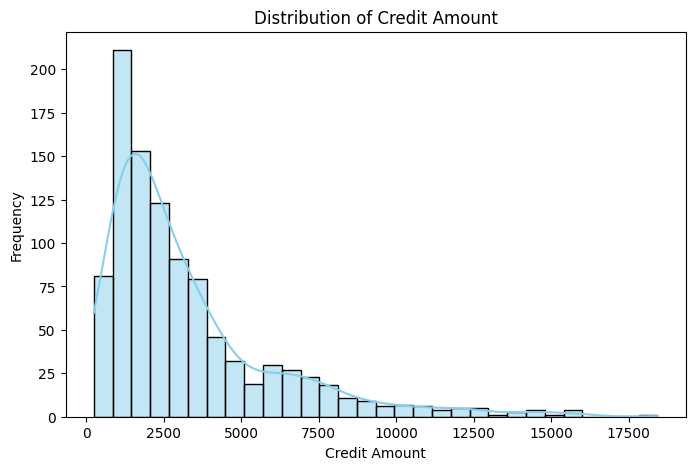

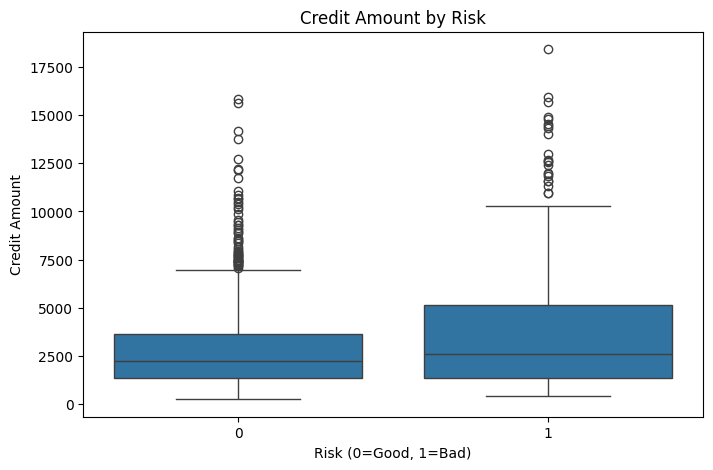

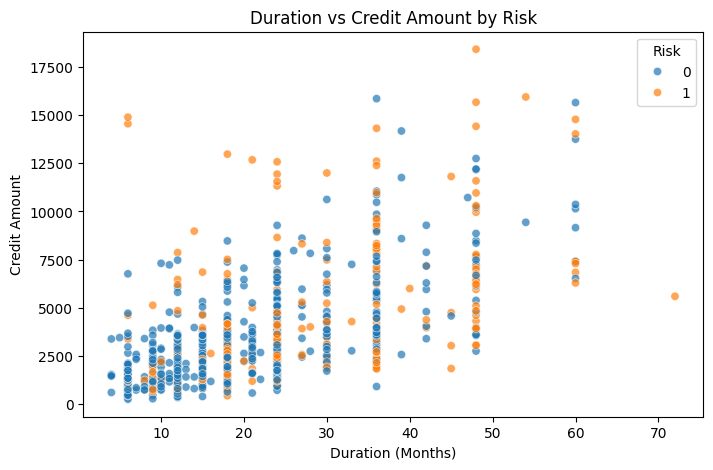

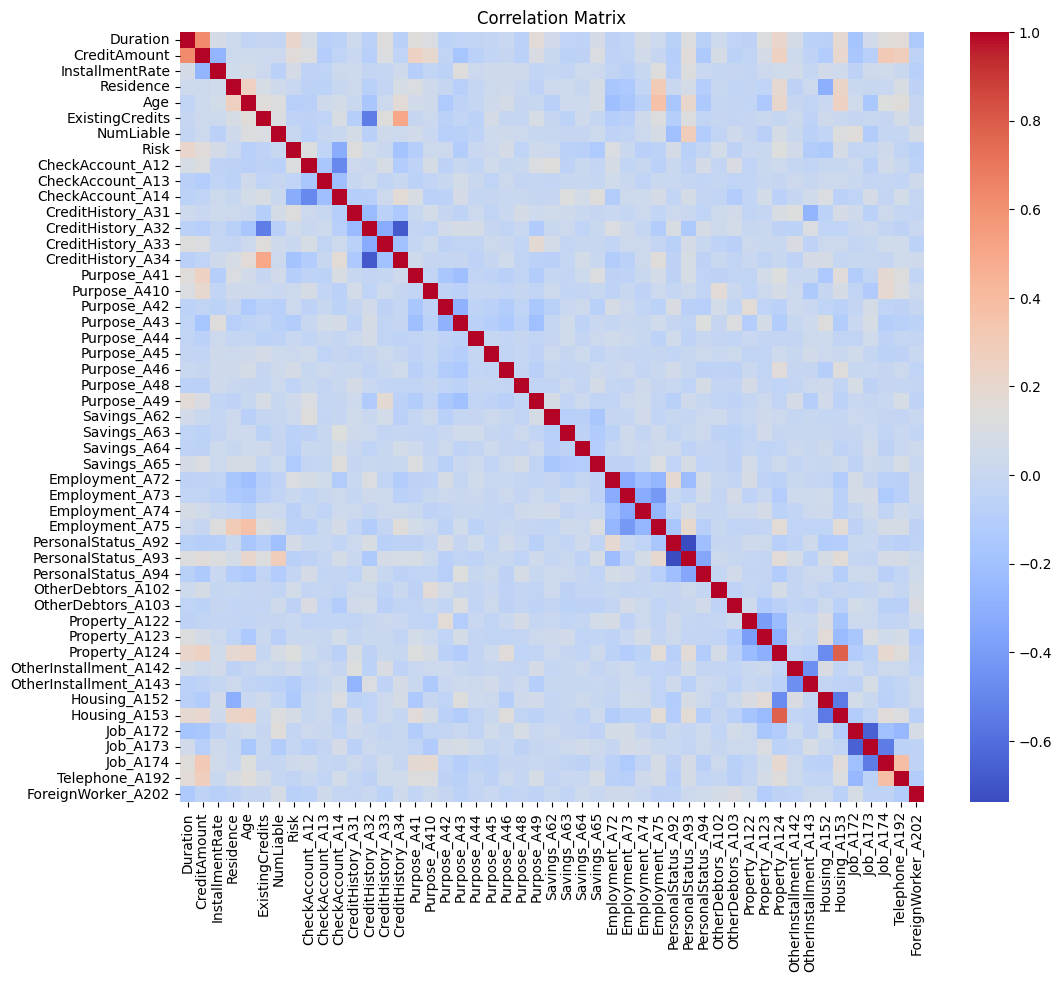

=== Top Correlations with Risk ===
Risk                  1.000000
Duration              0.214927
CreditAmount          0.154739
CreditHistory_A31     0.134448
Property_A124         0.125750
CheckAccount_A12      0.119581
Employment_A72        0.106397
Housing_A153          0.081556
PersonalStatus_A92    0.075493
InstallmentRate       0.072404
Name: Risk, dtype: float64


In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load dataset ---
df = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data",
    sep=' ',
    header=None
)

# Add column names
df.columns = [
    'CheckAccount', 'Duration', 'CreditHistory', 'Purpose', 'CreditAmount', 
    'Savings', 'Employment', 'InstallmentRate', 'PersonalStatus', 'OtherDebtors', 
    'Residence', 'Property', 'Age', 'OtherInstallment', 'Housing', 
    'ExistingCredits', 'Job', 'NumLiable', 'Telephone', 'ForeignWorker', 'Risk'
]

# Convert target
df['Risk'] = df['Risk'].map({1: 0, 2: 1})

# --- One-hot encoding ---
df_encoded = pd.get_dummies(df, drop_first=True)

# --- 1. Descriptive Statistics ---
print("=== Descriptive Statistics ===")
print(df_encoded.describe())

# --- 2. Visualizations ---

# Histogram of CreditAmount
plt.figure(figsize=(8,5))
sns.histplot(df_encoded['CreditAmount'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Credit Amount')
plt.xlabel('Credit Amount')
plt.ylabel('Frequency')
plt.show()

# Boxplot of CreditAmount vs Risk
plt.figure(figsize=(8,5))
sns.boxplot(x='Risk', y='CreditAmount', data=df_encoded)
plt.title('Credit Amount by Risk')
plt.xlabel('Risk (0=Good, 1=Bad)')
plt.ylabel('Credit Amount')
plt.show()

# Scatterplot: Duration vs CreditAmount colored by Risk
plt.figure(figsize=(8,5))
sns.scatterplot(x='Duration', y='CreditAmount', hue='Risk', data=df_encoded, alpha=0.7)
plt.title('Duration vs Credit Amount by Risk')
plt.xlabel('Duration (Months)')
plt.ylabel('Credit Amount')
plt.show()

# --- 3. Correlation Heatmap ---
plt.figure(figsize=(12,10))
corr = df_encoded.corr()
sns.heatmap(corr, cmap='coolwarm', annot=False, fmt=".2f", cbar=True)
plt.title('Correlation Matrix')
plt.show()

# Optional: Top correlations with target 'Risk'
target_corr = corr['Risk'].sort_values(ascending=False)
print("=== Top Correlations with Risk ===")
print(target_corr.head(10))

Feature Engineering
i did :Creating meaningful new features (ratios, aggregations)

Selecting top features based on correlation with Risk

In [132]:
import pandas as pd
from sklearn.model_selection import train_test_split

# --- 1. Load dataset ---
df = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data",
    sep=' ',
    header=None
)

# Add column names
df.columns = [
    'CheckAccount', 'Duration', 'CreditHistory', 'Purpose', 'CreditAmount', 
    'Savings', 'Employment', 'InstallmentRate', 'PersonalStatus', 'OtherDebtors', 
    'Residence', 'Property', 'Age', 'OtherInstallment', 'Housing', 
    'ExistingCredits', 'Job', 'NumLiable', 'Telephone', 'ForeignWorker', 'Risk'
]

# Map target
df['Risk'] = df['Risk'].map({1: 0, 2: 1})

# --- 2. One-hot encoding ---
df_encoded = pd.get_dummies(df, drop_first=True)

# --- 3. Feature Engineering ---
# Create meaningful ratio features
df_encoded['Installment_per_month'] = df_encoded['CreditAmount'] / df_encoded['Duration']
df_encoded['Credit_per_age'] = df_encoded['CreditAmount'] / df_encoded['Age']
df_encoded['Credit_per_existing'] = df_encoded['CreditAmount'] / (df_encoded['ExistingCredits'] + 1)

# --- 4. Feature Selection using correlation ---
corr = df_encoded.corr()['Risk'].abs().sort_values(ascending=False)

# Select features with correlation > 0.05
top_features = corr[corr > 0.05].index.tolist()
top_features.remove('Risk')  # Exclude target

# Prepare final X and y
X = df_encoded[top_features]
y = df_encoded['Risk']

# --- 5. Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("=== Feature Engineering & Selection Completed ===")
print(f"Selected Features ({len(top_features)}): {top_features}")
print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")

=== Feature Engineering & Selection Completed ===
Selected Features (29): ['CheckAccount_A14', 'Duration', 'CreditHistory_A34', 'Credit_per_age', 'CreditAmount', 'Credit_per_existing', 'Housing_A152', 'CreditHistory_A31', 'Savings_A65', 'Property_A124', 'CheckAccount_A12', 'OtherInstallment_A143', 'Purpose_A43', 'Employment_A72', 'Purpose_A41', 'Age', 'Savings_A64', 'ForeignWorker_A202', 'Housing_A153', 'PersonalStatus_A93', 'Employment_A74', 'PersonalStatus_A92', 'InstallmentRate', 'Savings_A63', 'Purpose_A46', 'OtherDebtors_A102', 'Employment_A75', 'OtherDebtors_A103', 'OtherInstallment_A142']
Training Features Shape: (800, 29)
Testing Features Shape: (200, 29)


Stage 4: Model Development,
By using class_weight='balanced', we tell the Random Forest to pay extra attention to the "Bad Risk" (30%) group. Without this, the model might try to cheat by simply guessing "Good" for everyone to get a 70% score. In banking, we care more about finding the "Bad" applicants than just having a high overall accuracy.

--- MODEL PERFORMANCE (Class Weights) ---
Accuracy: 0.77

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.93      0.85       140
           1       0.71      0.40      0.51        60

    accuracy                           0.77       200
   macro avg       0.74      0.66      0.68       200
weighted avg       0.76      0.77      0.75       200



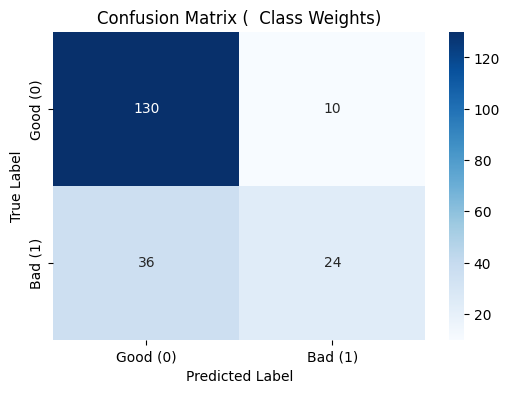

In [145]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Data Preparation ---
# Assuming df is your original dataframe with 'Risk' column

# Identify categorical columns (object type)
categorical_cols = df_encoded.select_dtypes(include=['object']).columns.tolist()


# Separate features and target
X = df_encoded.drop('Risk', axis=1)
y = df_encoded['Risk']

# Splitting 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 2. Baseline Model Training (with Class Weights) ---
rf_weighted = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    class_weight='balanced'  # Automatically balances classes
)
rf_weighted.fit(X_train, y_train)

# --- 3. Evaluation ---
y_pred = rf_weighted.predict(X_test)

print("--- MODEL PERFORMANCE (Class Weights) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --- 4. Confusion Matrix Visualization ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', 
    xticklabels=['Good (0)', 'Bad (1)'], 
    yticklabels=['Good (0)', 'Bad (1)']
)
plt.title('Confusion Matrix (  Class Weights)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

130 = Actual Good (0) correctly predicted as Good → True Negatives (TN) 
10 = Actual Bad (1) incorrectly predicted as Good → False Positives (FP)  (risky borrower approved)
36 = Actual Good (0) incorrectly predicted as Bad → False Negatives (FN)  (safe borrower rejected)
24 = Actual Bad (1) correctly predicted as Bad → True Positives (TP)  (risky borrower caught)



Accuracy: 0.77 (77%)
The model correctly classifies about 77 out of 100 applicants overall. That’s reasonable, but in credit risk the key is how well it handles the bad borrowers (defaults).



Good (0) borrowers
Precision 0.78 → When the model predicts “good,” it is correct 78% of the time.
Recall 0.93 → It catches 93% of all actual good borrowers (few safe customers are rejected).
F1‑score 0.85 → Very strong performance at approving safe applicants.
Bad (1) borrowers
Precision 0.71 → When the model predicts “bad,” it’s correct 71% of the time (some false alarms remain).
Recall 0.40 → It only catches 40% of actual risky borrowers (misses 60% of them).
F1‑score 0.51 → Moderate; indicates the model is better at avoiding false alarms than it is at finding most risky cases.

Business takeaway (what matters most)
Strength: The model is reliable at approving safe customers (high recall for Good), which avoids rejecting good borrowers and losing business.
 Weakness: It misses a large portion of risky borrowers (only 40% recall for Bad), meaning many defaults could still occur.
 Action focus: If reducing defaults is the priority, the main goal should be to increase recall for the risky class (Bad) while trying not to dramatically increase false positives (approving risky borrowers).

--- MODEL PERFORMANCE (Class Weights) ---
Accuracy: 0.79

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.94      0.86       210
           1       0.76      0.43      0.55        90

    accuracy                           0.79       300
   macro avg       0.78      0.69      0.71       300
weighted avg       0.79      0.79      0.77       300



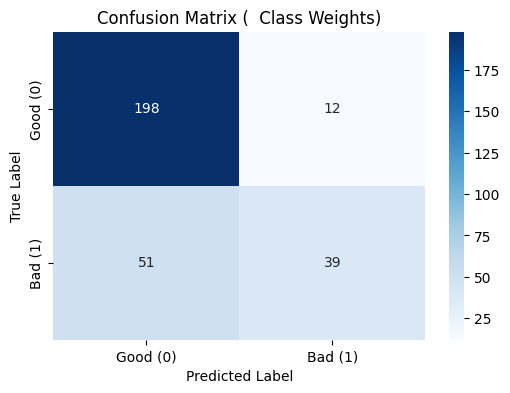

In [146]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Data Preparation ---
# Assuming df is your original dataframe with 'Risk' column

# Identify categorical columns (object type)
categorical_cols = df_encoded.select_dtypes(include=['object']).columns.tolist()


# Separate features and target
X = df_encoded.drop('Risk', axis=1)
y = df_encoded['Risk']

# Splitting 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# --- 2. Baseline Model Training (with Class Weights) ---
rf_weighted = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    class_weight='balanced'  # Automatically balances classes
)
rf_weighted.fit(X_train, y_train)

# --- 3. Evaluation ---
y_pred = rf_weighted.predict(X_test)

print("--- MODEL PERFORMANCE (Class Weights) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --- 4. Confusion Matrix Visualization ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', 
    xticklabels=['Good (0)', 'Bad (1)'], 
    yticklabels=['Good (0)', 'Bad (1)']
)
plt.title('Confusion Matrix (  Class Weights)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

198 = Actual Good (0) correctly predicted as Good → True Negatives (TN) 
12 = Actual Bad (1) incorrectly predicted as Good → False Positives (FP)  (risky borrower approved)
51 = Actual Good (0) incorrectly predicted as Bad → False Negatives (FN)  (safe borrower rejected)
39 = Actual Bad (1) correctly predicted as Bad → True Positives (TP)  (risky borrower caught)


Accuracy: 0.79 (79%)
The model correctly classifies about 79 of every 100 applicants overall. That’s solid, but in credit risk the most important part is how well it handles the bad borrowers (defaults).

Good (0) borrowers
Precision 0.80 → When the model predicts “good”, it’s correct 80% of the time.
Recall 0.94 → It catches 94% of actual good borrowers (very few safe applicants are rejected).
F1‑score 0.86 → Very strong performance at approving safe customers.
Bad (1) borrowers
Precision 0.76 → When the model predicts “bad”, it’s correct 76% of the time (some false alarms still exist).
Recall 0.43 → It only catches 43% of actual risky borrowers (misses more than half of them).
F1‑score 0.55 → Moderate performance; the model is better at avoiding false alarms than detecting all risky cases.

 Strength: The model is very good at approving safe customers (high recall for Good), which reduces lost opportunity from rejecting low-risk applicants.
 Weakness: It misses a lot of risky borrowers (it only catches 43% of them), meaning many defaults could still happen.
 Key priority: If your goal is to reduce defaults, focus on improving the model’s ability to find more of the actual bad borrowers (raise recall for class 1), while keeping false positives (approving risky borrowers) under control.

Accuracy: 0.7833
Classification Report:
              precision    recall  f1-score   support

    Good (0)       0.81      0.90      0.85       210
     Bad (1)       0.69      0.51      0.59        90

    accuracy                           0.78       300
   macro avg       0.75      0.71      0.72       300
weighted avg       0.77      0.78      0.77       300



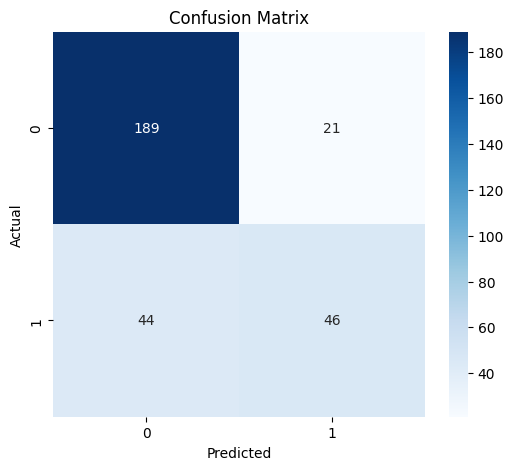

C:\Users\Admin\AppData\Local\Temp\ipykernel_17488\2645059123.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df_encoded, palette='magma')


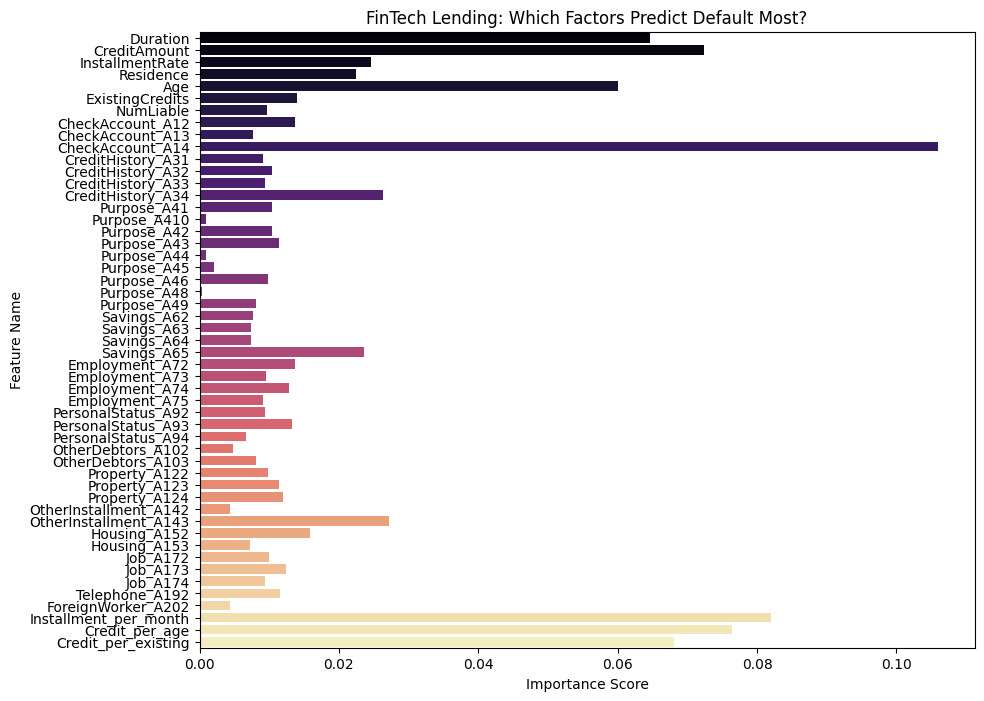

 Model Training Complete.
Top 3 Risk Predictors: 
           Feature  Importance
0         Duration    0.064691
1     CreditAmount    0.072334
2  InstallmentRate    0.024669


In [147]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

# 1. Initialize the Random Forest Classifier
# n_estimators=100: We are growing 100 different trees
# class_weight='balanced': Gives more weight to the minority 'Bad Risk' class
# random_state=42: Ensures the results are the same every time you run it
rf_model = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced', 
    random_state=42,
    max_depth=10  # We limit depth to prevent the model from 'memorizing' data Each tree is limited to 10 levels of splits.
)

# 2. Train (Fit) the model
rf_model.fit(X_train, y_train)

from sklearn.metrics import classification_report, accuracy_score

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

#  Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Print Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Good (0)", "Bad (1)"]))

#  Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 3. Calculate Feature Importance
# This identifies which factors (Age, Savings, etc.) are the best predictors of risk
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df_encoded = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df_encoded.sort_values(by='Importance', ascending=False)

# 4. Visualize the Top Predictors
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_encoded, palette='magma')
plt.title('FinTech Lending: Which Factors Predict Default Most?')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.show()

print(" Model Training Complete.")
print(f"Top 3 Risk Predictors: \n{feature_importance_df_encoded.head(3)}")

189 = Actual Good (0) correctly predicted as Good → True Negatives (TN) 
21 = Actual Bad (1) incorrectly predicted as Good → False Positives (FP)  (risky borrower approved)
44 = Actual Good (0) incorrectly predicted as Bad → False Negatives (FN)  (safe borrower rejected)
46 = Actual Bad (1) correctly predicted as Bad → True Positives (TP)  (risky borrower caught)


Accuracy: 0.7833 (78.3%)
The model correctly classifies about 78 out of 100 applicants overall. That’s solid, but in credit risk we focus on how well it catches the bad borrowers.

Good (0) borrowers
Precision 0.81 → When the model predicts “good,” it is correct 81% of the time.
Recall 0.90 → It finds 90% of actual good borrowers (few safe applicants get rejected).
F1‑score 0.85 → Very strong performance on approving safe applicants.
Bad (1) borrowers
Precision 0.69 → When the model predicts “bad,” it’s correct 69% of the time (still some false alarms).
Recall 0.51 → It only catches 51% of actual risky borrowers (misses nearly half of them).
F1‑score 0.59 → Moderate; showing the model is better at avoiding false alarms than finding all risky cases.

Business takeaway (what matters most)
 Strength: The model is very good at approving safe customers (high recall for Good), which avoids unnecessary lost business.
 Weakness: It only catches about half of the risky borrowers (recall 51%), meaning many defaults could still slip through.
 Key priority: If your goal is to reduce defaults, focus on improving the model’s ability to find more of the actual bad borrowers (increase recall for class 1) while keeping false positives (approving risky borrowers) as low as possible.

Trying other models

Test Set Accuracy: 0.7300

Classification Report:
              precision    recall  f1-score   support

    Good (0)       0.85      0.75      0.79       210
     Bad (1)       0.54      0.69      0.60        90

    accuracy                           0.73       300
   macro avg       0.69      0.72      0.70       300
weighted avg       0.76      0.73      0.74       300



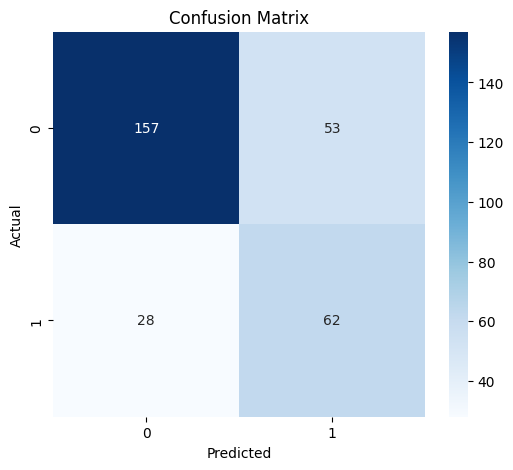

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML tools
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import make_scorer, f1_score, accuracy_score, roc_auc_score, classification_report, confusion_matrix

# Models
from xgboost import XGBClassifier

# -----------------------------
# 1. Train-Test Split (Optional)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# -----------------------------
# 2. Define the XGBoost model
# -----------------------------
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    scale_pos_weight=(len(y[y==0]) / len(y[y==1])),  # handle imbalance
    #use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
# -----------------------------
# 3. Train the model
# -----------------------------
xgb_model.fit(X_train, y_train)

# -----------------------------
# 4. Evaluate on test set
# -----------------------------
y_pred = xgb_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Good (0)", "Bad (1)"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


157 = Actual Good (0) correctly predicted as Good → True Negatives (TN) 
53 = Actual Bad (1) incorrectly predicted as Good → False Positives (FP)  (this is the costly mistake: risky borrower approved)
28 = Actual Good (0) incorrectly predicted as Bad → False Negatives (FN)  (safe borrower declined)
62 = Actual Bad (1) correctly predicted as Bad → True Positives (TP)  (risky borrower caught)

Test Set Accuracy: 0.7300 (73.0%)
The model correctly classifies about 73 out of 100 applicants overall. That’s decent, but in credit risk we care more about whether the bad borrowers are caught.



Good (0) borrowers
Precision 0.85 → When the model predicts “good,” it is correct 85% of the time.
Recall 0.75 → It captures 75% of actual good borrowers.
F1-score 0.79 → Balanced performance at approving safe customers.
Bad (1) borrowers
Precision 0.54 → When the model predicts “bad,” it’s correct only 54% of the time (so nearly half are false alarms).
Recall 0.69 → It identifies 69% of actual risky borrowers (good, but could improve).
F1-score 0.60 → Moderate; suggests room to better separate risky vs safe.


 Business meaning (what you should take away)
 The model is reasonably good at catching risky borrowers (it identifies most of them), which helps reduce defaults.
 However, it still lets 53 risky borrowers through as “good” (false positives), which is the most expensive mistake because those loans can default.
 To improve business impact, focus on reducing false positives (risky borrowers approved) while keeping the ability to detect real risk.

In [140]:
lgb_model = LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    class_weight='balanced',
    random_state=42,
    verbose=-1  # <-- suppress info/warning messages
)

Test Set Accuracy: 0.7350

Classification Report:
              precision    recall  f1-score   support

    Good (0)       0.85      0.76      0.80       140
     Bad (1)       0.55      0.68      0.61        60

    accuracy                           0.73       200
   macro avg       0.70      0.72      0.70       200
weighted avg       0.76      0.73      0.74       200



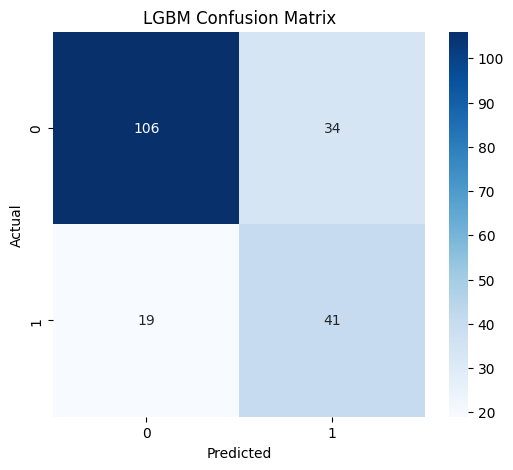

In [ ]:
# LightGBM
from lightgbm import LGBMClassifier


# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# Train Model
# -----------------------------
lgb_model.fit(X_train, y_train)

# -----------------------------
# 5️ Evaluate on Test Set
# -----------------------------
y_pred = lgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Good (0)", "Bad (1)"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LGBM Confusion Matrix")
plt.show()

True Negatives (106): Actual good borrowers correctly predicted as good 
False Positives (34): Actual bad borrowers incorrectly predicted as good  (this is the most costly error because it means risky borrowers are approved)
False Negatives (19): Actual good borrowers incorrectly predicted as bad  (these are safe customers who get wrongly rejected)
True Positives (41): Actual bad borrowers correctly predicted as bad  (this is what you want to maximize to prevent defaults)

Accuracy: 0.7350 (73.5%)
Out of 100 loan applications, the model correctly classifies about 74 of them overall.

By class:
Good borrowers (0)
Precision 0.85 → When the model says “good,” it’s correct 85% of the time.
Recall 0.76 → It catches 76% of actual good borrowers.
F1‑score 0.80 → Strong overall performance for approving safe customers.
Bad borrowers (1)
Precision 0.55 → When the model says “bad,” it’s correct only 55% of the time (nearly half are false alarms).
Recall 0.68 → It detects 68% of actual risky borrowers (good, but could catch more).
F1‑score 0.61 → Moderate performance; there’s room for improvement.



 Business takeaway (clear & actionable)
 The model is reasonably good at finding risky borrowers (it catches most of them), which helps prevent defaults.
 But it still lets 34 risky borrowers slip through as “good”, which can cost money if they default.
 To improve credit decisioning, focus on reducing false positives (those 34 risky borrowers approved as good) without sacrificing the ability to detect real risk.
Raptor mini (Preview) • 1x

In [142]:
# Import libraries
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# -------------------------------
# Assume X, y are ready
# -------------------------------

# Split dataset into train and test (e.g., 70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Initialize Logistic Regression with balanced class weight
logreg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  # handle imbalance
    random_state=42
)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
# Train the model
logreg.fit(X_train, y_train)

# Predict on test set
y_pred = logreg.predict(X_test)
y_prob = logreg.predict_proba(X_test)[:, 1]  # probabilities for ROC AUC

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, pos_label=1)  # F1 for risky borrowers
roc_auc = roc_auc_score(y_test, y_prob)

print("Logistic Regression Performance ")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 (Bad Risk): {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Logistic Regression Performance 
Accuracy: 0.7267
F1 (Bad Risk): 0.6204
ROC AUC: 0.7996
Accuracy: 0.7266666666666667

Confusion Matrix:
 [[151  59]
 [ 23  67]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.72      0.79       210
           1       0.53      0.74      0.62        90

    accuracy                           0.73       300
   macro avg       0.70      0.73      0.70       300
weighted avg       0.77      0.73      0.74       300



C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


True Negatives (151) = Good borrowers correctly labeled good 
False Positives (59) = Bad borrowers incorrectly labeled good  (this is costly because it leads to defaults)
False Negatives (23) = Good borrowers incorrectly labeled bad  (this hurts revenue through missed approvals)
True Positives (67) = Bad borrowers correctly labeled bad  (what we want to maximize)

Class 0 = Good borrowers
Precision 0.87 → When the model says “good,” it’s right 87% of the time.
Recall 0.72 → It correctly identifies 72% of all true good borrowers.
F1‑score 0.79 → Strong balance for the good class.
Class 1 = Bad borrowers (critical group)
Precision 0.53 → When the model says “bad,” it’s only correct 53% of the time → high number of false alarms.
Recall 0.74 → It catches 74% of all actual risky borrowers → good for reducing defaults.
F1‑score 0.62 → Moderate performance; more room to improve.

Business takeaway (what matters most)
 The model does a good job finding risky borrowers (recall 74%), which helps reduce defaults.
 However, it labels many safe borrowers as risky (precision only 53%), meaning a lot of good customers could be rejected.
 If your priority is to avoid defaults, this model is useful — but you should still work to reduce the number of false alarms so you don’t hurt revenue by turning away too many good applicants.

Next improvement ideas (if you want to act on it)
Adjust the decision threshold to trade off fewer false positives vs. missing more bad borrowers.
Add calibration / probability-based scoring so you can set risk cutoffs based on business cost (e.g., cost of default vs. cost of rejection).
Try adding features or using regularization to improve the model’s ability to separate good and bad borrowers more clearly.

In [144]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Features and target
X = df_encoded.drop('Risk', axis=1)  # all columns except target
y = df_encoded['Risk']                # 0 = Good, 1 = Bad

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVM
svm_model = SVC(kernel='linear', class_weight='balanced', random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Predict
y_pred = svm_model.predict(X_test_scaled)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.755

Confusion Matrix:
 [[105  35]
 [ 14  46]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.75      0.81       140
           1       0.57      0.77      0.65        60

    accuracy                           0.76       200
   macro avg       0.73      0.76      0.73       200
weighted avg       0.79      0.76      0.76       200



True Negatives (105): Correctly predicted good borrowers as good.
False Positives (35): Incorrectly predicted bad borrowers as good → most costly error (this is the one lenders want to minimize).
False Negatives (14): Incorrectly predicted good borrowers as bad → opportunity loss.
True Positives (46): Correctly predicted bad borrowers as bad (what we want to maximize).


Class 0 = Good borrower
Precision 0.88 → When the model says “good,” it’s right 88% of the time.
Recall 0.75 → It catches 75% of all good borrowers.
F1‑score 0.81 → Solid balance between precision and recall for good borrowers.
Class 1 = Bad borrower (the critical group)
Precision 0.57 → When the model says “bad,” it’s right 57% of the time (means ~43% are false alarms).
Recall 0.77 → It finds 77% of all true risky borrowers (good for catching defaults).
F1‑score 0.65 → Balanced performance but room to improve.

 Business takeaway (clear & actionable)
 Good news: The model catches most of the risky borrowers (77% recall for bad cases) — this is the priority for reducing defaults.
 Concern: When it flags someone as risky, it’s only correct 57% of the time, meaning many safe borrowers may be rejected unnecessarily.
 If the goal is to minimize costly defaults, this model is doing a decent job of finding bad borrowers, but it could still reduce false alarms (false positives) to avoid rejecting too many good customers.
Next steps (if you want to improve it further)
Lower false positives (reduce the 35 bad borrowers misclassified as good) by tuning thresholds, using class weights, or trying ensemble/hybrid models.
Track the cost impact: “How much does a false positive cost vs. a false negative?” Use that to guide tuning.


In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score
import numpy as np

# Assuming X_train, X_test, y_train, y_test are already defined from previous cells

# Create a pipeline with scaling and SVM
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True, class_weight='balanced', random_state=42))
])

# Define parameter grid for tuning
param_grid = {
    'svm__C': [0.1, 1, 10, 100],  # Regularization parameter
    'svm__kernel': ['linear', 'rbf'],  # Kernel types
    'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1]  # Gamma for rbf kernel
}

# Use StratifiedKFold for cross-validation to handle imbalance
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid search with focus on F1 for bad borrowers
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='f1',  # Optimize for F1-score on positive class (bad borrowers)
    n_jobs=-1,
    verbose=1
)

# Fit the grid search
grid_search.fit(X_train, y_train)

# Best model
best_svm = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")

# Predict on test set
y_pred = best_svm.predict(X_test)
y_prob = best_svm.predict_proba(X_test)[:, 1]

# Evaluate
print("\n--- Improved SVM Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 (Bad Risk): {f1_score(y_test, y_pred, pos_label=1):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_prob):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["Good (0)", "Bad (1)"]))

# Threshold Tuning for Better FP/Recall Balance
thresholds = np.arange(0.1, 0.9, 0.05)
best_threshold = 0.5
best_f1 = f1_score(y_test, y_pred, pos_label=1)

for thresh in thresholds:
    y_pred_thresh = (y_prob >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred_thresh, pos_label=1)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh

print(f"\nBest Threshold: {best_threshold:.2f} with F1: {best_f1:.4f}")

# Final predictions with best threshold
y_pred_final = (y_prob >= best_threshold).astype(int)
print("\n--- Final SVM with Threshold Tuning ---")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_final))
print("\nClassification Report:\n", classification_report(y_test, y_pred_final, target_names=["Good (0)", "Bad (1)"]))